In [19]:
%matplotlib inline
# %matplotlib widget
%load_ext autoreload
%autoreload 2

import matplotlib
import torch
import logging 
from pathlib import Path
import random
import numpy as np

import method.datasets as ds
import method.preprocess.preprocess as ps
import method.core.pipeline as pipe
import method.models.rnn.rnn as model

from method.metrics import metrics
from logging_tools.config import setup_logging
from method.viz import plot_data, plot_results, plot_data_compare

import data_configs.test_data_config as config

CONFIGS_PATH = Path("configs")
DATASET_CONFIG = ds.DatasetConfig.from_dict(config.EXECUTE_CONFIG["dataset"])

setup_logging()
logger = logging.getLogger(__name__)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO     Preprocessor.transform start

INFO     Pipeline making step 'feature_selector'

INFO     Pipeline making step 'shifter'

INFO     Pipeline making step 'drop_intervals'

INFO     Pipeline making step 'filter'

INFO     Pipeline making step 'interpolation'

INFO     Pipeline making step 'smoother'

INFO     Pipeline making step 'scaler'

INFO     Pipeline making step 'splitter'

INFO     Preprocessor.transform end (0.14)s

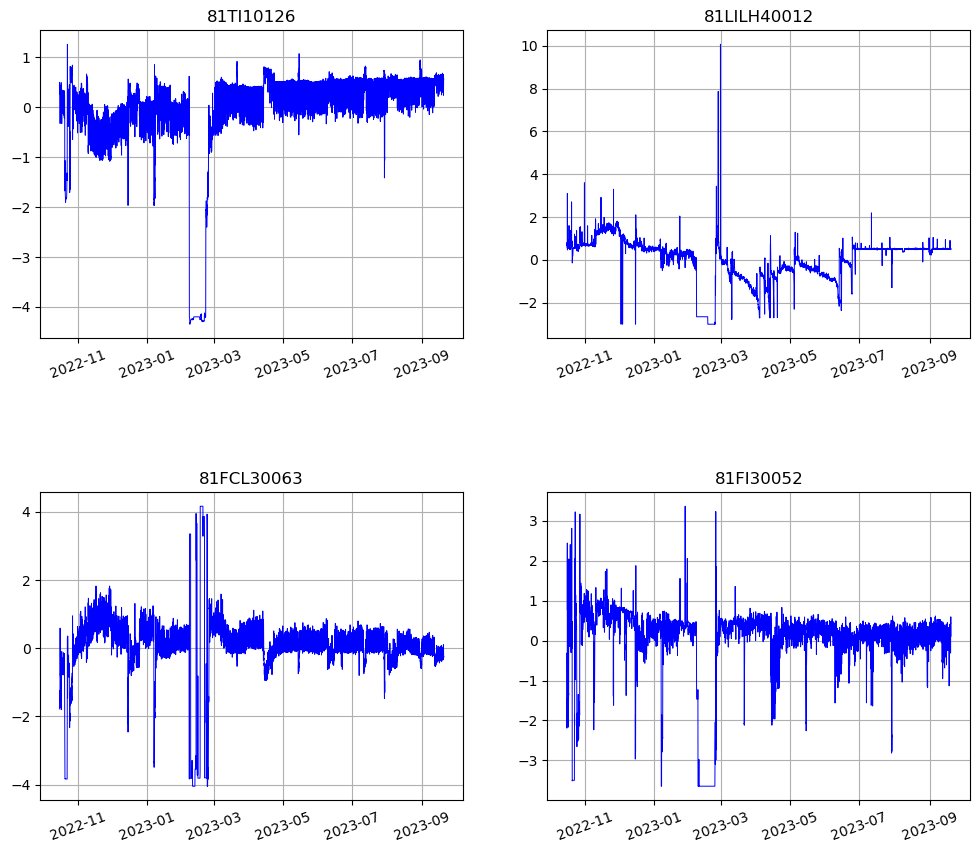

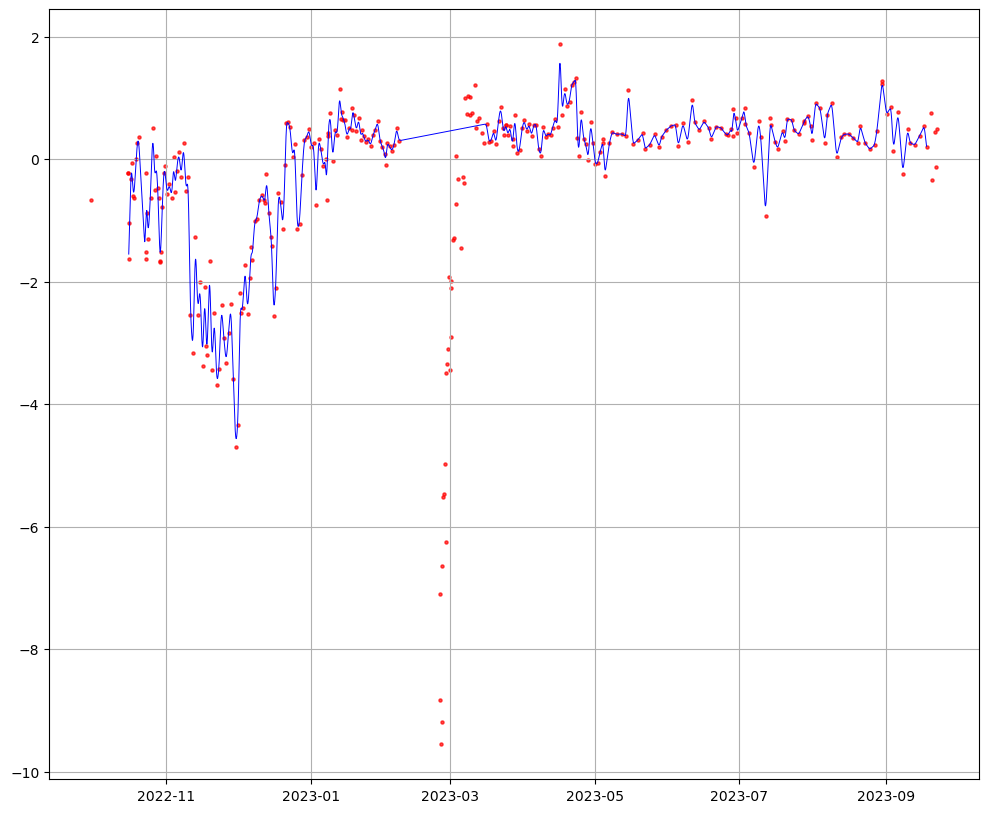

In [20]:
data_raw = ds.LoadDatasetStep(DATASET_CONFIG).fit_transform()


preprocess_config = ps.PreprocessConfig.from_dict(config.EXECUTE_CONFIG["preprocess"])
preprocessor = ps.Preprocessor(preprocess_config)

data = preprocessor.fit_transform(data_raw)

data_merged = data.merge_data()
ds_raw = data_raw.train.replace(new_y_scaler=data.train.y_scaler)
target_raw_scaled = ds_raw.scale(scale_y=True).y
target = data_merged.train.y
plot_data(data_merged.train.X.dropna(), plot_type="plot")
plot_data_compare(target_raw_scaled.dropna(), target.dropna())

INFO     RNN training model

INFO     Computing best lag using spearman correlation...

INFO     epoch 0: train: 0.4558, lr: 1.000e-02, valid: 0.1390, best_valid: 0.1390

INFO     epoch 10: train: 0.0905, lr: 1.000e-02, valid: 0.1195, best_valid: 0.0395

INFO     epoch 20: train: 0.0693, lr: 1.000e-02, valid: 0.1434, best_valid: 0.0395

INFO     epoch 30: train: 0.0500, lr: 1.000e-02, valid: 0.1945, best_valid: 0.0395

INFO     epoch 40: train: 0.0352, lr: 1.000e-02, valid: 0.2027, best_valid: 0.0395

INFO     epoch 50: train: 0.0334, lr: 1.000e-02, valid: 0.1673, best_valid: 0.0395

INFO     RNN Model trained

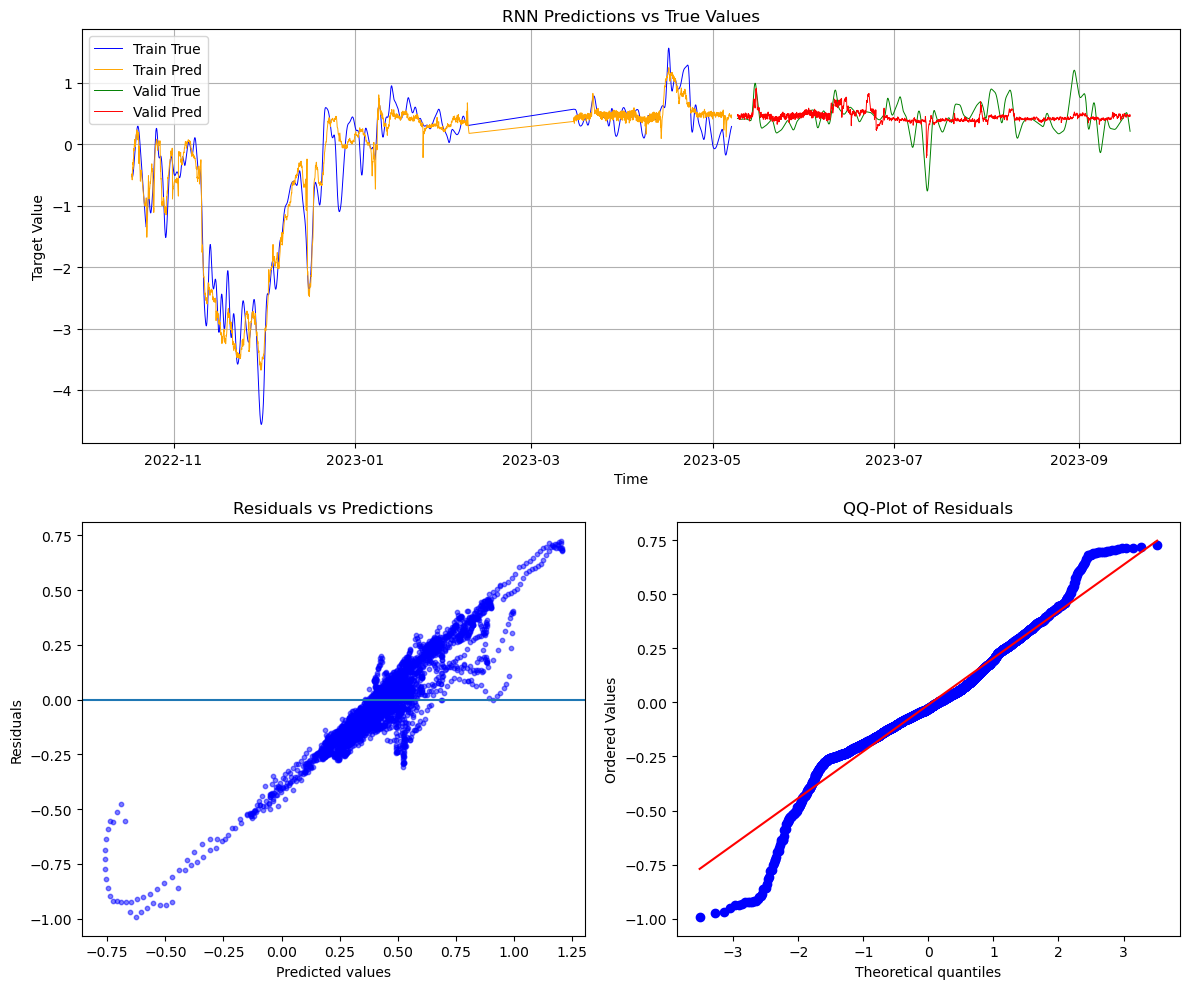

INFO     Metrics for Valid:

INFO                                                                                                               
         MAE                  0.161626                                                                             
         rMSE                 0.220135                                                                             
         MAPE                 0.807724                                                                             
         Pearson (p-value)    0.000000                                                                             
         Pearson              0.424713                                                                             
         R2                   0.175494                                                                             
         Hinge                0.084155                                                                             
         dtype: float64

In [21]:
torch.manual_seed(0)
np.random.seed(42)
random.seed(42)

rnn_config = model.RNNConfig.from_dict(config.EXECUTE_CONFIG["model"])
rnn = model.RNN(rnn_config)

steps = [("rnn", rnn)] 
full_pipeline = pipe.Pipeline(steps)  # type: ignore
result = full_pipeline.fit_transform(data)

plot_results(result)

logger.debug("Metrics for Train:")
logger.debug("\n%s", metrics(**result["train"], cone=0.1))
logger.info("Metrics for Valid:")
logger.info("\n%s", metrics(**result["valid"], cone=0.1))